<a href="https://colab.research.google.com/github/vitriadwiernita/TUGAS-ANALISIS-KORELASI/blob/main/VITRIA_DWI_ERNITA_(PROJEK_ANREG).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis Pengaruh Durasi Penggunaan Smartphone Harian terhadap Tingkat Produktivitas Kerja Menggunakan Regresi Linear Sederhana**

---
---

Perkembangan teknologi digital meningkatkan durasi penggunaan smartphone dalam kehidupan sehari-hari. Penggunaan yang berlebihan berpotensi memengaruhi tingkat fokus dan produktivitas kerja. Oleh karena itu, penting untuk menganalisis apakah terdapat hubungan signifikan antara durasi penggunaan smartphone harian dan tingkat produktivitas kerja.





***-MASIH DALAM PERBAIKAN-***

Saving Smartphone_Usage_Productivity_Dataset_50000.csv to Smartphone_Usage_Productivity_Dataset_50000.csv

=== 5 DATA TERATAS ===
   Daily_Phone_Hours  Work_Productivity_Score
0                1.3                        6
1                1.2                        5
2                5.3                        5
3                5.8                        2
4                7.9                        4

=== MISSING VALUES ===
Daily_Phone_Hours          0
Work_Productivity_Score    0
dtype: int64

=== DETEKSI OUTLIER (IQR METHOD) ===

Variabel: Daily_Phone_Hours
Batas bawah: -4.3
Batas atas : 17.3
Jumlah outlier: 0

Variabel: Work_Productivity_Score
Batas bawah: -4.5
Batas atas : 15.5
Jumlah outlier: 0


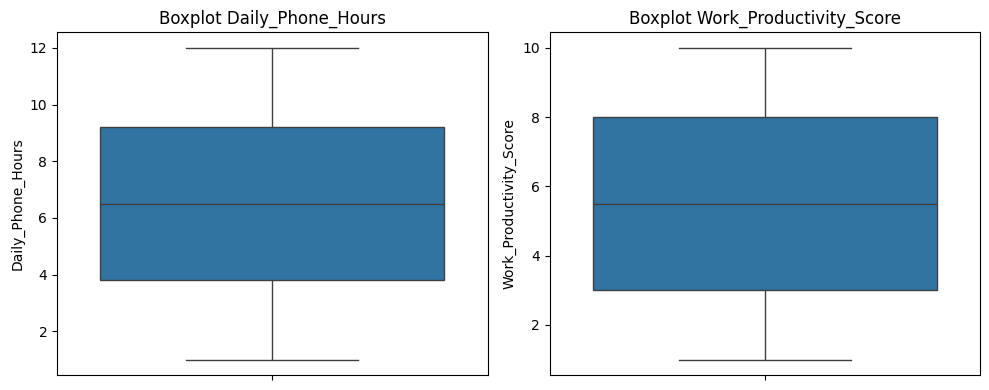


=== STATISTIK DESKRIPTIF ===
       Daily_Phone_Hours  Work_Productivity_Score
count       50000.000000             50000.000000
mean            6.509116                 5.503760
std             3.170903                 2.874806
min             1.000000                 1.000000
25%             3.800000                 3.000000
50%             6.500000                 5.500000
75%             9.200000                 8.000000
max            12.000000                10.000000

=== ANALISIS KORELASI (Pearson) ===
Koefisien Korelasi (r) = -0.0024
p-value = 0.590888
Interpretasi: Korelasi sangat lemah/tidak ada

=== ANALISIS REGRESI LINEAR ===

=== RINGKASAN MODEL ===
                               OLS Regression Results                              
Dep. Variable:     Work_Productivity_Score   R-squared:                       0.000
Model:                                 OLS   Adj. R-squared:                 -0.000
Method:                      Least Squares   F-statistic:                  

/tmp/ipykernel_1683/2259270663.py:127: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  slope_p_value = model.pvalues[1]


In [2]:
# ============================================
# ANALISIS REGRESI LINEAR SEDERHANA
# Daily Phone Hours vs Work Productivity Score
# ============================================

# 1. IMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from google.colab import files
uploaded = files.upload()

# ============================================
# 2. IMPORT DATA
# ============================================

data = pd.read_csv("Smartphone_Usage_Productivity_Dataset_50000.csv")

# Pilih variabel yang digunakan
data_sw = data[["Daily_Phone_Hours", "Work_Productivity_Score"]]

print("\n=== 5 DATA TERATAS ===")
print(data_sw.head())

# ============================================
# 3. MISSING VALUES
# ============================================

print("\n=== MISSING VALUES ===")
total_missing = data_sw.isnull().sum()
print(total_missing)

# ============================================
# 4. OUTLIER (METODE IQR)
# ============================================

print("\n=== DETEKSI OUTLIER (IQR METHOD) ===")

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return lower_bound, upper_bound, outliers

for col in data_sw.columns:
    lb, ub, outliers = detect_outliers_iqr(data_sw[col])
    print(f"\nVariabel: {col}")
    print(f"Batas bawah: {round(lb,2)}")
    print(f"Batas atas : {round(ub,2)}")
    print(f"Jumlah outlier: {len(outliers)}")

# Visualisasi Boxplot
plt.figure(figsize=(10,4))
for i, col in enumerate(data_sw.columns):
    plt.subplot(1,2,i+1)
    sns.boxplot(y=data_sw[col])
    plt.title(f"Boxplot {col}")
plt.tight_layout()
plt.show()

# ============================================
# 5. STATISTIK DESKRIPTIF
# ============================================

print("\n=== STATISTIK DESKRIPTIF ===")
print(data_sw.describe())

# ============================================
# 6. ANALISIS KORELASI
# ============================================

print("\n=== ANALISIS KORELASI (Pearson) ===")

correlation, p_value = stats.pearsonr(
    data_sw["Daily_Phone_Hours"],
    data_sw["Work_Productivity_Score"]
)

print(f"Koefisien Korelasi (r) = {round(correlation,4)}")
print(f"p-value = {round(p_value,6)}")

# Interpretasi otomatis
if abs(correlation) >= 0.9:
    print("Interpretasi: Korelasi sangat kuat")
elif abs(correlation) >= 0.7:
    print("Interpretasi: Korelasi kuat")
elif abs(correlation) >= 0.5:
    print("Interpretasi: Korelasi sedang")
elif abs(correlation) >= 0.3:
    print("Interpretasi: Korelasi lemah")
else:
    print("Interpretasi: Korelasi sangat lemah/tidak ada")

# ============================================
# 7. ANALISIS REGRESI LINEAR SEDERHANA
# ============================================

print("\n=== ANALISIS REGRESI LINEAR ===")

X = data_sw["Daily_Phone_Hours"]
Y = data_sw["Work_Productivity_Score"]

# Tambahkan konstanta (intercept)
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print("\n=== RINGKASAN MODEL ===")
print(model.summary())

# ============================================
# 8. UJI HIPOTESIS SLOPE (β1)
# ============================================

alpha = 0.05
slope_p_value = model.pvalues[1]

print("\n=== UJI HIPOTESIS UNTUK SLOPE (β1) ===")
print("H0: β1 = 0 (Tidak ada hubungan linear)")
print("H1: β1 ≠ 0 (Ada hubungan linear)")
print(f"p-value = {round(slope_p_value,6)}")

if slope_p_value < alpha:
    print("KEPUTUSAN: Tolak H0")
    print("KESIMPULAN: Terdapat hubungan linear yang signifikan")
else:
    print("KEPUTUSAN: Gagal Tolak H0")
    print("KESIMPULAN: Tidak terdapat hubungan linear yang signifikan")

# ============================================
# 9. VALIDASI MODEL (TRAIN-TEST SPLIT)
# ============================================

print("\n=== VALIDASI MODEL ===")

X_train, X_test, y_train, y_test = train_test_split(
    data_sw[["Daily_Phone_Hours"]],
    data_sw["Work_Productivity_Score"],
    test_size=0.2,
    random_state=42
)

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

model_train = sm.OLS(y_train, X_train_const).fit()

predictions = model_train.predict(X_test_const)

mse = mean_squared_error(y_test, predictions)

print(f"MSE (Mean Squared Error) = {round(mse,4)}")

catatan :

- scatterplot
- ulang yg sa